# Dynamic Query Analysis

The purpose of this analysis is to investigate the use of the first hit in a track to initialise the dynamic queries. There is a possibility that this approach may miss displaced hits, reducing the efficiency of the tagger.

## First hit initialisation

The first step is to investigate whether we do actually have an issue in using the first hit to initialise the dynamic queries. To do this, we wish to find the fraction of truth particles without a track that are classified as a first hit.

In [5]:
import h5py
test_path = '/share/rcif2/mmangat/logs/TRK-v8-3l-fast-fix-vec_20260316-T104827/ckpts/epoch=020-val_loss=1.48183_test_eval.h5'
first_hits_path = '/share/rcif2/mmangat/logs/HF-900MeV-eta4_20260305-T105911/ckpts/epoch=022-val_loss=0.03377_test_eval.h5'

def print_tree(name, obj):
    indent = "  " * name.count("/")
    if isinstance(obj, h5py.Group):
        print(f"{indent}[{name}]")
    elif isinstance(obj, h5py.Dataset):
        print(f"{indent}{name}  shape={obj.shape} dtype={obj.dtype}")

print("First hit data:")
with h5py.File(first_hits_path, "r") as f:
    print("/")
    f['29800'].visititems(print_tree)
    print("\n")

print("Track data:")
with h5py.File(test_path, "r") as f:
    print("/")
    f['29800'].visititems(print_tree)

First hit data:
/
[inputs]
  inputs/hit_charge_frac  shape=(1, 9370) dtype=float16
  inputs/hit_eta  shape=(1, 9370) dtype=float16
  inputs/hit_geta  shape=(1, 9370) dtype=float16
  inputs/hit_gphi  shape=(1, 9370) dtype=float16
  inputs/hit_leta  shape=(1, 9370) dtype=float16
  inputs/hit_lphi  shape=(1, 9370) dtype=float16
  inputs/hit_lx  shape=(1, 9370) dtype=float16
  inputs/hit_ly  shape=(1, 9370) dtype=float16
  inputs/hit_lz  shape=(1, 9370) dtype=float16
  inputs/hit_phi  shape=(1, 9370) dtype=float16
  inputs/hit_r  shape=(1, 9370) dtype=float16
  inputs/hit_s  shape=(1, 9370) dtype=float16
  inputs/hit_u  shape=(1, 9370) dtype=float16
  inputs/hit_v  shape=(1, 9370) dtype=float16
  inputs/hit_valid  shape=(1, 9370) dtype=bool
  inputs/hit_x  shape=(1, 9370) dtype=float16
  inputs/hit_y  shape=(1, 9370) dtype=float16
  inputs/hit_z  shape=(1, 9370) dtype=float16
[preds]
  [preds/final]
    [preds/final/hit_filter]
      preds/final/hit_filter/hit_is_first  shape=(1, 9370) dty

In [6]:
import h5py
import numpy as np

test_path = '/share/rcif2/mmangat/logs/TRK-v8-3l-fast-fix-vec_20260316-T104827/ckpts/epoch=020-val_loss=1.48183_test_eval.h5'
first_hits_path = '/share/rcif2/mmangat/logs/HF-900MeV-eta4_20260305-T105911/ckpts/epoch=022-val_loss=0.03377_test_eval.h5'

total_den = 0
total_num = 0
per_event_stats = []
truth_first_hit_r = []
pred_first_hit_r = []


with h5py.File(test_path, "r") as tf, h5py.File(first_hits_path, "r") as fhf:
    common_keys = sorted(set(tf.keys()) & set(fhf.keys()), key=lambda x: int(x) if x.isdigit() else x)

    print(f"Found {len(common_keys)} common events")


    for sample_key in common_keys:
        t = tf[sample_key]
        fh = fhf[sample_key]

        # -------- Track file --------
        truth_particle_valid = t['targets/particle_valid'][0].astype(bool, copy=False)
        truth_particle_id = t['targets/particle_id'][0]
        truth_particle_hit_valid = t['targets/particle_hit_valid'][0].astype(bool, copy=False)

        pred_track_valid = t['preds/final/track_valid/track_valid'][0].astype(bool, copy=False)
        pred_track_hit_valid = t['preds/final/track_hit_valid/track_hit_valid'][0].astype(bool, copy=False)

        truth_particle_id = truth_particle_id[truth_particle_valid]
        truth_particle_hit_valid = truth_particle_hit_valid[truth_particle_valid]
        pred_track_hit_valid = pred_track_hit_valid[pred_track_valid]

        # -------- First-hit file --------
        hit_valid = fh['targets/hit_valid'][0].astype(bool, copy=False)
        hit_particle_id = fh['targets/hit_particle_id'][0]
        hit_is_first_truth = fh['targets/hit_is_first'][0].astype(bool, copy=False)
        hit_is_first_pred = fh['preds/final/hit_filter/hit_is_first'][0].astype(bool, copy=False)
        hit_r = fh['inputs/hit_r'][0].astype(np.float16, copy=False)

        # -------- Fast no-track logic for threshold = 0.0 --------
        if pred_track_hit_valid.shape[0] > 0 and truth_particle_hit_valid.shape[0] > 0:
            # which hits are used by at least one predicted track?
            pred_used_hits = pred_track_hit_valid.any(axis=0)  # (n_hits,)

            # truth particle has a track iff any of its valid hits is used by a predicted track
            has_track = (truth_particle_hit_valid & pred_used_hits[None, :]).any(axis=1)
        else:
            has_track = np.zeros(len(truth_particle_id), dtype=bool)

        no_track_particle_ids = truth_particle_id[~has_track]
          
        first_hit_of_no_track_particle = (
            hit_valid
            & hit_is_first_truth
            & np.isin(hit_particle_id, no_track_particle_ids)
        )

        for particle in no_track_particle_ids:
            hit_id = np.where((hit_particle_id == particle) & hit_is_first_truth)[0]

            if len(hit_id) > 1:
                print(f"Warning: Multiple first hits found for truth particle {particle}")
            if len(hit_id) == 0:
                continue  # or handle this case
            hit_id = hit_id[0]
            truth_first_hit_r.append(hit_r[hit_id])
            
            if hit_is_first_pred[hit_id]:
                pred_first_hit_r.append(hit_r[hit_id])

        den = len(no_track_particle_ids)
        num = int((first_hit_of_no_track_particle & hit_is_first_pred).sum())

        total_den += den
        total_num += num

        per_event_stats.append({
            "sample_key": sample_key,
            "den": den,
            "num": num,
            "fraction": num / den if den > 0 else np.nan,
        })
        #print(f"Event {sample_key} processed")

overall_fraction = total_num / total_den if total_den > 0 else np.nan

print("\nOverall results")
print(f"Total no-track truth first hits: {total_den}")
print(f"Predicted as first hit: {total_num}")
print(f"Overall fraction: {overall_fraction:.6f}")

Found 100 common events
2922
3959
1366
2500
2028
2647
1835
1980
2177
1644
2751
1684
750
2046
1080
4240
699
3543
1562
8946
1613
6557
821
472
1600
2448
1435
2609
2027
1338
4128
1235
1047
6659
1796
1836
6500
2225
2644
1406
2103
1181
2613
2157
1421
1950
4225
2431
2396
1298
2213
7513
33
753
2984
1350
3374
4437
4944
2218
3340
5619
1552
1100
1771
2471
7144
1229
2291
2599
3411
5119
3416
1848
1449
3150
2542
2147
622
2548
1081
1162
1277
3647
3157
3238
1567
943
3958
2352
1841
1619
3336
1632
2237
1174
1161
1979
5422
1974
4604
2618
1159
2208
3268
1382
1715
2190
3165
7186
905
2316
914
3050
3266
2834
2892
2532
1874
2086
2454
6653
1630
2551
2784
2745
1888
3039
1178
1647
1305
2204
88
1418
1514
1255
3053
3033
1181
1114
2718
1392
2338
3862
1780
3010
3216
2057
2392
3488
3316
6981
4057
3866
3116
1274
2943
6797
2559
2540
4648
1825
1401
4659
1962
1071
1846
795
9909
5726
2048
1848
904
13
4304
2856
1616
3316
1183
1108
9419
1754
2321
555
741
7316
3071
2236
1724
3582
3040
2095
872
2164
1407
2183
4605
1149
3550
3

In [7]:
hit_r

array([1.444 , 0.864 , 1.363 , ..., 1.143 , 1.2705, 1.501 ], dtype=float16)

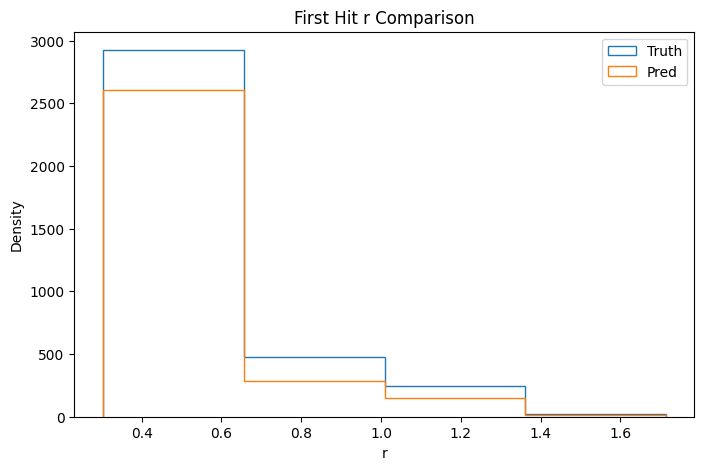

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

truth_r = np.array(truth_first_hit_r)
pred_r = np.array(pred_first_hit_r)

bins = np.linspace(
    min(truth_r.min(), pred_r.min()),
    max(truth_r.max(), pred_r.max()),
    5
)

plt.figure(figsize=(8, 5))

plt.hist(truth_r, bins=bins, histtype='step', density=False, label='Truth')
plt.hist(pred_r, bins=bins, histtype='step', density=False, label='Pred')

plt.xlabel('r')
plt.ylabel('Count')
plt.title('First Hit r Comparison')
plt.legend()

plt.show()